In [177]:
import numpy as np
import matplotlib.pyplot as plt

# 11.1

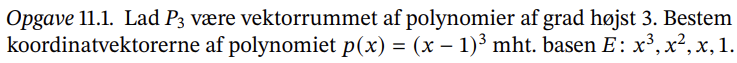

Først pakker jeg polynomiet ud: 
$$p(x) = (x-1)^3 = x^3 - 3x^2 + 3x - 1$$

Jeg  ved at koordinatvektoren $[p]_E$ er løsningen på ligningssystemet:
$$A[p]_E = b$$

Her er $b = p(x)$, og $A$'s søjler er netop basen givet ved $E$.

Dermed må koordinatvektoren være givet ved:
$$[p]_E = \begin{bmatrix} 1 \\ -3 \\ 3 \\ -1 \end{bmatrix}$$

# 11.2

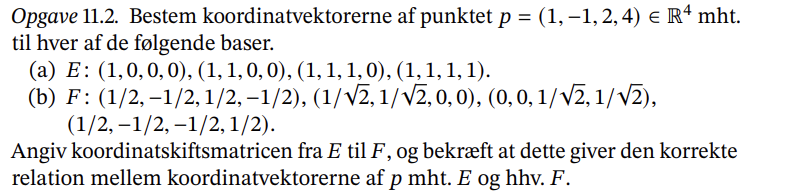

In [178]:
p = np.array([1, -1, 2, 4])[:, np.newaxis]
p

array([[ 1],
       [-1],
       [ 2],
       [ 4]])

## (a)

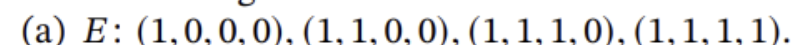

Vi ved at $E$ er en basis, og dermed må alle vektorene være lineært uafhængige. Hvis dette er tilfældet, så kan vi samle dem til en kvadratisk matrix $A$, som vil have en entydigt bestemt løsning for alle $b$ i: 
$$A[b]_E = b$$

Vi kan altså vha backsubstitution eller rækkeoperationer bestemme koordinatvektoren for $p$ mht. $E$:

In [179]:
# Angivelse af back substitution funktion
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [180]:
A = np.triu(np.ones((4,4), dtype=float))
A

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [181]:
pE = back_subs(A, p)
pE

array([[ 2.],
       [-3.],
       [-2.],
       [ 4.]])

## (b)

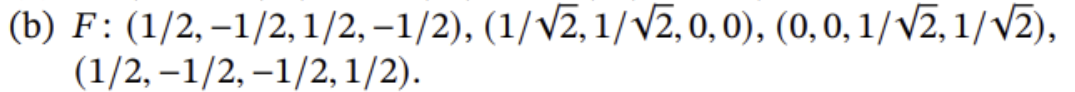

Denne opgave kan løses på samme måde som ovenfor.

Dog kan den også løses lettere. Læg mærke til at samlingen af vektorer er ortonormale. På baggrund af dette må matricen $B$ med samlingen som vektorer altså være ortogonal, og så ved vi at: $B^T = B^{-1}$.

Vi kan nu bestemme $[p]_F = B^T p$

In [182]:
B = np.array([[1/2, 1/np.sqrt(2), 0, 1/2],
              [-1/2, 1/np.sqrt(2), 0, -1/2],
              [1/2, 0, 1/np.sqrt(2), -1/2],
              [-1/2, 0, 1/np.sqrt(2), 1/2]])

B

array([[ 0.5       ,  0.70710678,  0.        ,  0.5       ],
       [-0.5       ,  0.70710678,  0.        , -0.5       ],
       [ 0.5       ,  0.        ,  0.70710678, -0.5       ],
       [-0.5       ,  0.        ,  0.70710678,  0.5       ]])

In [183]:
pF = B.T @ p
pF

array([[0.        ],
       [0.        ],
       [4.24264069],
       [2.        ]])

## Bonus

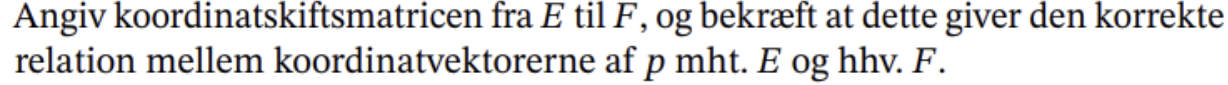

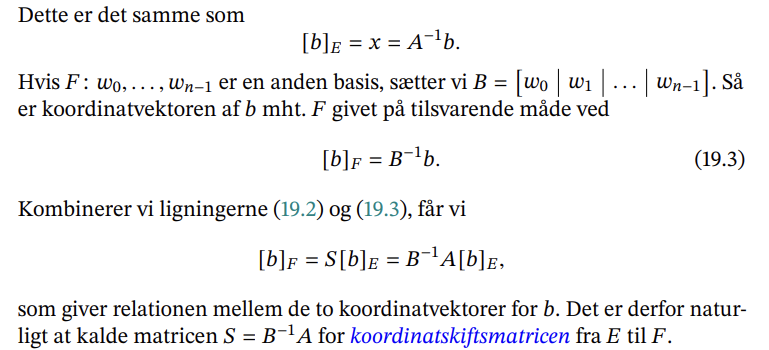

Den sidste formel ovenfor fortæller os netop hvad vi skal gøre:

$$S = B^{-1} A$$
Her er $A$ en matrix hvis søjler er vektorerne i $E$, og $B$ en matrix hvis søjler er vektorerne i $F$:

In [184]:
S = B.T @ A
S

array([[ 0.5       ,  0.        ,  0.5       ,  0.        ],
       [ 0.70710678,  1.41421356,  1.41421356,  1.41421356],
       [ 0.        ,  0.        ,  0.70710678,  1.41421356],
       [ 0.5       ,  0.        , -0.5       ,  0.        ]])

Vi kan tjekke om dette er rigtigt ved at sende $[p]_E$ over i $F$ ved at gøre følgende: $[p]_F = S [p]_E$:

In [185]:
pFnew = S @ pE

pF - pFnew

array([[0.],
       [0.],
       [0.],
       [0.]])

Som vi kan se ovenfor bliver $[p]_E$ sendt korrekt over i $F$, da der ikke er nogen forskel på de to som vi fandt.

# 11.3

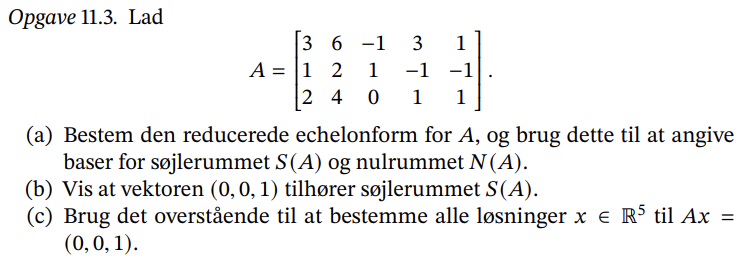

## (a)

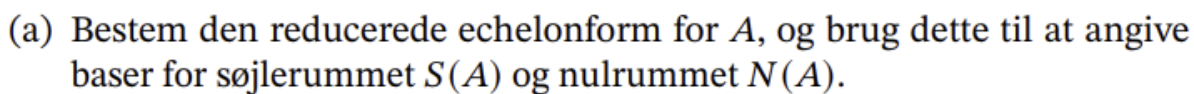

Først reducerer jeg matricen til echelonform:

In [186]:
A = np.array([[3, 6, -1, 3, 1],
              [1, 2, 1, -1, -1],
              [2, 4, 0, 1, 1]], dtype=float)
Aold = np.copy(A)

A, Aold

(array([[ 3.,  6., -1.,  3.,  1.],
        [ 1.,  2.,  1., -1., -1.],
        [ 2.,  4.,  0.,  1.,  1.]]),
 array([[ 3.,  6., -1.,  3.,  1.],
        [ 1.,  2.,  1., -1., -1.],
        [ 2.,  4.,  0.,  1.,  1.]]))

In [187]:
A[0] /= 3
A

array([[ 1.        ,  2.        , -0.33333333,  1.        ,  0.33333333],
       [ 1.        ,  2.        ,  1.        , -1.        , -1.        ],
       [ 2.        ,  4.        ,  0.        ,  1.        ,  1.        ]])

In [188]:
A[1] -= A[0]
A[2] -= 2*A[0]
A

array([[ 1.        ,  2.        , -0.33333333,  1.        ,  0.33333333],
       [ 0.        ,  0.        ,  1.33333333, -2.        , -1.33333333],
       [ 0.        ,  0.        ,  0.66666667, -1.        ,  0.33333333]])

In [189]:
A[1] *= 3/4
A

array([[ 1.        ,  2.        , -0.33333333,  1.        ,  0.33333333],
       [ 0.        ,  0.        ,  1.        , -1.5       , -1.        ],
       [ 0.        ,  0.        ,  0.66666667, -1.        ,  0.33333333]])

In [190]:
A[2] -= 2/3*A[1]
A

array([[ 1.        ,  2.        , -0.33333333,  1.        ,  0.33333333],
       [ 0.        ,  0.        ,  1.        , -1.5       , -1.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ]])

In [191]:
A[0] += 1/3 * A[1]
A

array([[ 1. ,  2. ,  0. ,  0.5,  0. ],
       [ 0. ,  0. ,  1. , -1.5, -1. ],
       [ 0. ,  0. ,  0. ,  0. ,  1. ]])

In [192]:
A[1] += A[2]
A

array([[ 1. ,  2. ,  0. ,  0.5,  0. ],
       [ 0. ,  0. ,  1. , -1.5,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  1. ]])

Vi kan nu se at vi har et pivot element i 0., 2. og 4. søjle, og dermed udspænder disse søjler vores søjlerum $S(A)$:

$S(A) = \text{span} \{\begin{bmatrix} 3 \\ 1 \\ 2 \end{bmatrix}, \begin{bmatrix} -1 \\ 1 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 \\ -1 \\ 1 \end{bmatrix}\}$

Vi kan bestemme nulrummet $N(A)$, som alle de elementer som bliver sendt over i $0$-elementet i $\mathbb{R}^3$. Ud fra den reducerede echelonform af $A$, så kan vi bestemme følgende 3 ligninger, fordi echelonformen og normal $A$ er ens grundet vi blot har brugt elementære rækkeoperationer.

$$x_0 + 2x_1 + \frac{1}{2} x_3 = 0$$
$$x_2 - \frac{3}{2} x_3 = 0$$
$$x_4 = 0$$

Vi vil nu isolere $x_0$, $x_2$ og $x_4$ da de to tilhørende søjler har noget pivot element.
$$x_0 = -2x_1 - \frac{1}{2} x_3$$
$$x_2 = \frac{3}{2} x_3$$
$$x_4 = 0$$

Vi har nu at vores nulrum må været givet ved:

$$\begin{bmatrix} -2x_1 - \frac{1}{2}x_3 \\ x_1 \\ \frac{3}{2}x_3 \\ x_3 \\ 0 \end{bmatrix} = x_1\begin{bmatrix} -2 \\ 1 \\ 0 \\ 0 \\ 0 \end{bmatrix} + x_3 \begin{bmatrix} -\frac{1}{2} \\ 0 \\ \frac{3}{2} \\ 1 \\ 0 \end{bmatrix}$$

Dermed er vores nulrum $N(A) = \text{span}\{\begin{bmatrix} -2 \\ 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}, \begin{bmatrix} -\frac{1}{2} \\ 0 \\ \frac{3}{2} \\ 1 \\ 0 \end{bmatrix}\}$

## (b)

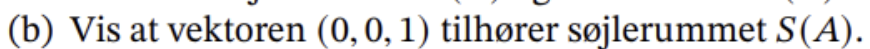

Dette er tydeligvist rigtigt. Vi har 3 pivot søjler i vores matrix. Disse 3 søjler er lineært uafhængige og må dermed udspænde hele $\mathbb{R^3}$.

Vi kan vise dette ved at opstille et ligningssystem $A_s x = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$ hvor $A_s$ er en matrix som kun har pivot søjlerne.

In [193]:
As = Aold[:, 0:5:2]
As

array([[ 3., -1.,  1.],
       [ 1.,  1., -1.],
       [ 2.,  0.,  1.]])

In [194]:
b = np.array([0, 0, 1], dtype=float) [:, np.newaxis]
b

array([[0.],
       [0.],
       [1.]])

In [195]:
x = np.linalg.solve(As, b)
x

array([[0.],
       [1.],
       [1.]])

Vi kan ovenfor se at den givne vektor blot er en sum af de to sidste vektorer i søjlerummet.

## (c)

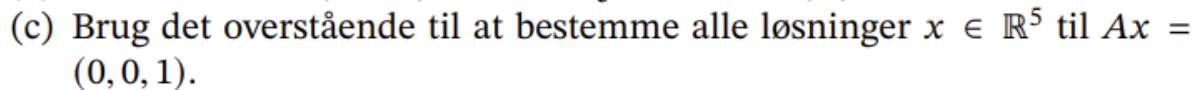

Vi ved at numrummet altid mapper over i $0$. Dermed må en linearkombination af løsningen og nulrummet, altid mappe over i det rigtige.

Løsningen fra før kan overføres til vores oprindelige matrix $A$ som værende: $\begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \\ 1 \end{bmatrix}$.

Enhver løsning vil altså være givet ved:

$$x = \begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \\ 1 \end{bmatrix} + x_1\begin{bmatrix} -2 \\ 1 \\ 0 \\ 0 \\ 0 \end{bmatrix} + x_3 \begin{bmatrix} -\frac{1}{2} \\ 0 \\ \frac{3}{2} \\ 1 \\ 0 \end{bmatrix}$$

# 11.4

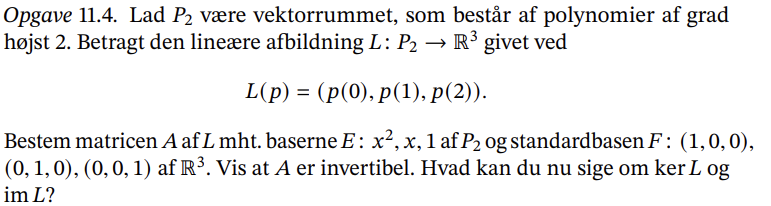

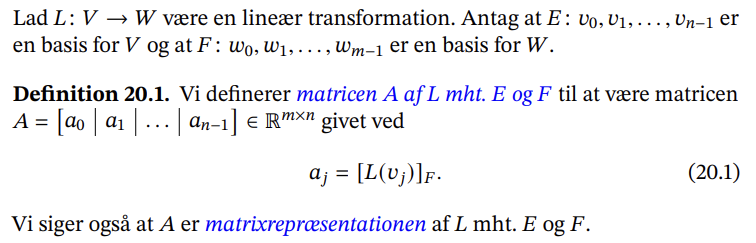

Vi ved at $F$ er givet ved standard basen, og derfor kan vi sige at: $a_j = [L(v_j)]_F = A^{-1} L(v_j) = L(v_j)$

Nu sender jeg basisvektorerne i $E$ for $P_2$, igennem den lineære transformation for at bestemme søjler til matricen $A$:

In [196]:
# x^2, for 0, 1 og 2
a0 = np.array([0, 1, 4])[:, np.newaxis]
# x, for 0, 1 og 2
a1 = np.array([0, 1, 2])[:, np.newaxis]
# 1, for 0, 1 og 2
a2 = np.array([1, 1, 1])[:, np.newaxis]


$A$ er invertibel hvis vi har et pivotelement i hver søjle, eller hvis $\det(A) \neq 0$:

In [197]:
A = np.hstack([a0, a1, a2], dtype=float)
A

array([[0., 0., 1.],
       [1., 1., 1.],
       [4., 2., 1.]])

In [198]:
A[[0, 1]] = A[[1, 0]] 
A[2] -= 4*A[0]
A[[2, 1]] = A[[1, 2]] 
A[1] *= -1/2

A

array([[ 1. ,  1. ,  1. ],
       [-0. ,  1. ,  1.5],
       [ 0. ,  0. ,  1. ]])

Fordi der er et pivot element i alle søjler, så er matricen $A$ invertibel.

Fordi vi har et pivot element i alle søjler i matricen $A$, så er vores nulrum blot $0$-elementet i $P_2$. Dermed kan vi på baggrund af følgende sige:

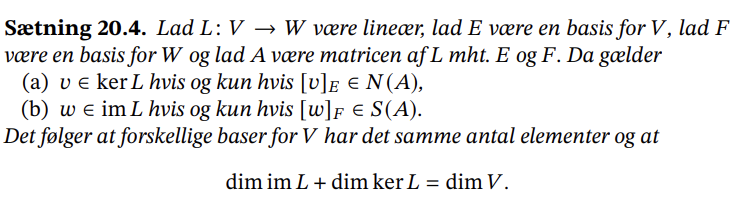

Her kan vi betragte vores lineære transformation på formen:

$$A[x]_E = [x]_F$$

Vi kan nu se at $\ker L$ er de vektorer $v$, hvis koordinatskiftede vektor $[v]_E$ ligger i nulrummet $N(A)$. Vi ved, fordi vi har et pivot element i alle søjler, at vores nulrum blot indeholder ${0}$, da det er den eneste løsning for lineært uafhængige lineære kombinationer. Hvis vi så transformerer dette element tilbage fra basen $E$, så får vi $A_E[v]_E = v =  0 * x^2 + 0 * x + 0 * 1 = 0$.

Ligeledes kan vi se at $\text{im } L$ er de vektorer, hvis transformerede ligger i søjle rummet af $A$. Vi ved at $S(A) = \mathbb{R}^3$, dette kan nu transformeres om til normale koordinater igen:
$A_F [w]_F = I_3 [w]_F = [w]_F = w, \forall [w]_F \in \mathbb{R^3}$.

Altså må vi have at vores billedmængde af $L$ er: $\text{im } L = \mathbb{R^3}$

# 11.5

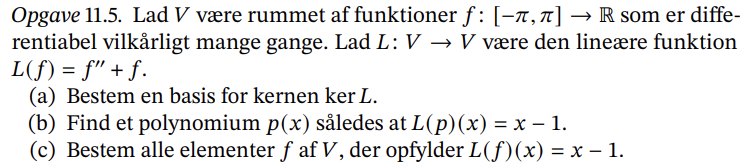

## (a)

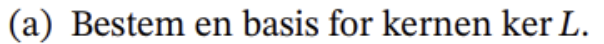

Der er mange vilkårligt mange gange differentiable funktioner. Dog er der ikke rigtig nogen af dem som går ud med hinanden ved mindre de er lig hinanden.

Her er der kun to funktioner, som besidder egenskaben at deres dobbelte afledte er lig sig selv med modsat fortegn. Disse to er $\sin(x)$ og $\cos(x)$.

Dermed ugør disse to en basis for kernen af $L$.

## (b)

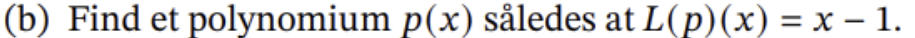

Ved at prøve sig lidt frem så finder man frem til at: $L(x - 1) = (x-1)'' + x-1 = 0 + x - 1 = x - 1$

## (c)

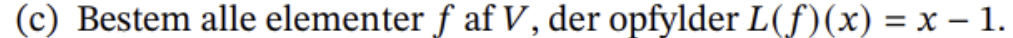

Her kan vi bruge samme trick som vi gjorde tidligere, med at vi kan ligge en lineær kombination af vektorerne som udspænder nulrummer på, og stadig få det samme:

Her vil alle elementer være givet ved: $f(x) = x-1 + a \sin(x) + b \cos(x)$

# 11.6

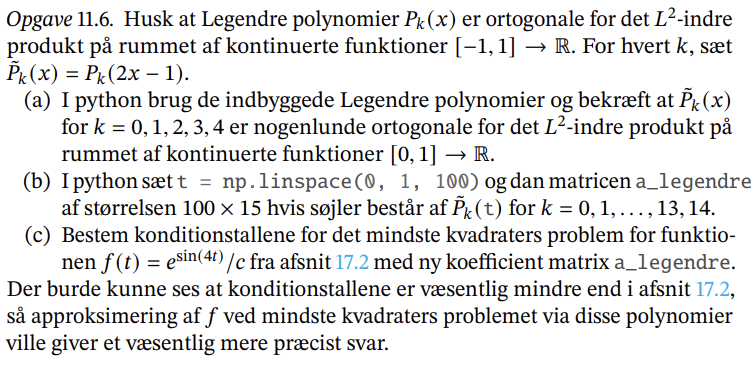

## (a)

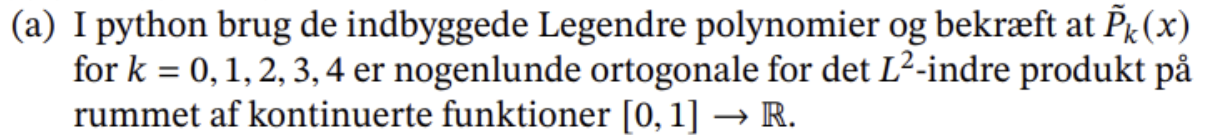

In [199]:
import numpy as np
from numpy.polynomial import Polynomial as P
from numpy.polynomial import Legendre as L
t, h = np.linspace(0, 1, 100, retstep=True)
def trapz(f, h):
    return h * (f[0] + 2*np.sum(f[1:-1]) + f[-1]) / 2
gram = np.empty((5, 5))
for i in range(5):
    for j in range(5):
        gram[i, j] = trapz(L.basis(i)(2 * t - 1) * L.basis(j)(2 * t - 1), h)
print(np.round(gram, 3))
print('Største indgang væk fra diagonalen')
print(np.max(np.abs(np.triu(gram, 1))))


[[1.    0.    0.    0.    0.   ]
 [0.    0.333 0.    0.    0.   ]
 [0.    0.    0.2   0.    0.   ]
 [0.    0.    0.    0.143 0.   ]
 [0.    0.    0.    0.    0.112]]
Største indgang væk fra diagonalen
0.0004419929631706089


Disse polynomier er tilsyneladende ortogonale da grammatricen er en diagonal matrix.

## (b)

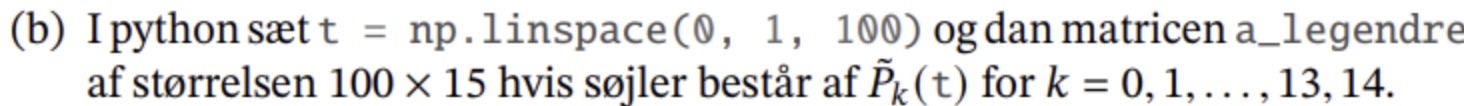

In [200]:
a_legendre = np.empty((100, 15))
for i in range(15):
    a_legendre[:, i] = L.basis(i)(2 * t - 1)
print(a_legendre)

[[ 1.         -1.          1.         ...  1.         -1.
   1.        ]
 [ 1.         -0.97979798  0.94000612 ... -0.05724604  0.15121378
  -0.23257809]
 [ 1.         -0.95959596  0.88123661 ... -0.39097064  0.40542671
  -0.3872585 ]
 ...
 [ 1.          0.95959596  0.88123661 ... -0.39097064 -0.40542671
  -0.3872585 ]
 [ 1.          0.97979798  0.94000612 ... -0.05724604 -0.15121378
  -0.23257809]
 [ 1.          1.          1.         ...  1.          1.
   1.        ]]


## (c)

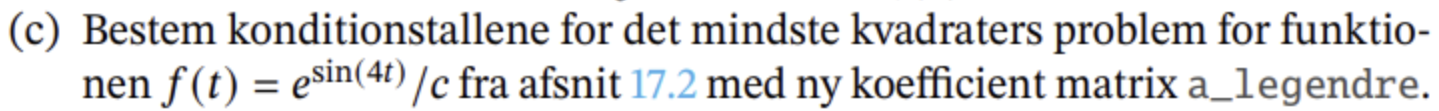

Kopieret direkte fra notesættet, nu bruges der blot $a_{legendre}$ i stedet for $a$.

In [201]:
m = 100
cols = 15
t = np.linspace(0, 1, m)
c = 2006.787453104852
b = np.exp(np.sin(4 * t))[:, np.newaxis] / c


In [202]:
u, s, vt = np.linalg.svd(a_legendre, full_matrices=False)
kappa_a = s[0] / s[-1]
print(f'{kappa_a = :e}')

kappa_a = 5.268431e+00


In [203]:
proj_b = u @ (u.T @ b)
cos_theta = np.linalg.norm(proj_b) / np.linalg.norm(b)
print(np.degrees(np.arccos(cos_theta)))


0.00021462687599597396


In [204]:
x = vt.T @ (np.diag(1/s) @ (u.T @ b))
eta = s[0] * np.linalg.norm(x) / np.linalg.norm(proj_b)
print(f'{eta = :e}')


eta = 1.265333e+00


In [205]:
kond_x_b = kappa_a / (eta * cos_theta)
kond_x_a_højst = (kappa_a +
(kappa_a**2 * np.sqrt(1-cos_theta**2) / (eta * cos_theta)))
print(f'{kond_x_b = :e}')
print(f'{kond_x_a_højst = :e}')


kond_x_b = 4.163670e+00
kond_x_a_højst = 5.268513e+00


Dette nye konditionstal på $5.27$ er betydeligt bedre end det i notesættet, som ligger på: $2.27*10^{10}$